____
# Distance to coast


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from diagnosis import update_dict, dataset_coloc_combs, dataset_coloc_combs, prepared_drifters, prepared_wd, prepared_alti, compute_mean_square, compute_mean_square_groupby, plot_error, extract_mean_geo

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [2]:
dt=12
alti_product_key='swot2km'
drifter_preprocess = ''
drifter_preprocess_param=''
from diagnosis import define_coloc_source
colocs_sources = define_coloc_source('12h', drifter_preprocess, drifter_preprocess_param)

_______
# Compute and project (x = cross, y = alg)

In [3]:
# SURFACE
base_dic = dict(dt='12h', 
        drifter_preprocess = drifter_preprocess,
        drifter_preprocess_param=drifter_preprocess_param,
        alti_product_key=alti_product_key,
        alti_diff_method = 'fromduacsv',
        alti_diff_method_param = '',
        ggd_var = 'fromduacsv',
        wd_product_key = 'era5', 
        wd_model ='rio', 
        wd_depth = '0')


comb_list = [base_dic]
l = ['L3-2km',]
ds0 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds0['comb'] = ds0['id_comb']
ds0['id_comb'] = ('id_comb',l)
distance_to_coast = ds0.distance_to_coast.isel(id_comb = 0)
ds0['distance_to_coast'] = ('row_number', distance_to_coast.values)

#DEPTH 15M
base_dic = update_dict(base_dic, dict(wd_depth = '15'))
comb_list = [base_dic]

ds15 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds15['comb'] = ds15['id_comb']
ds15['id_comb'] = ('id_comb',l)
distance_to_coast = ds15.distance_to_coast.isel(id_comb = 0)
ds15['distance_to_coast'] = ('row_number', distance_to_coast.values)

DS = xr.concat([ds0.where(ds0.depth==0, drop=True), ds15.where(ds15.depth==15, drop=True)], dim='row_number')
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<dt).dropna('row_number')
DS = DS.where((abs(DS.ggde)<1e-4) & (abs(DS.ggdn)<1e-4), drop=True)

307771
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fromduacsv__fromduacsv__era5_rio0
Identified SWOT and drifter outliers have been removed
307771
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fromduacsv__fromduacsv__era5_rio15
Identified SWOT and drifter outliers have been removed


In [4]:
DS = extract_mean_geo(DS)

________
# Distance_to_coast

In [5]:
compute_error = 'centrallimit'

df = DS.isel(id_comb=0).to_dataframe()
dtc_bins = np.linspace(0, 200e3, 20)
df['dtc_cut'] = pd.cut(df['distance_to_coast'], dtc_bins, labels=(dtc_bins[1:] + dtc_bins[:-1])/2)
dsdtc = compute_mean_square_groupby(df, groupby = 'dtc_cut', dirname = ('e', 'n'), compute_error =compute_error, vars_errors = ['Ex_ggd', 'Ey_ggd'] )
dsdtc = dsdtc.where(dsdtc.nb_coloc>0).dropna('dtc_cut')
dsdtc['dtc_cut'] = dsdtc.dtc_cut/1000

ok


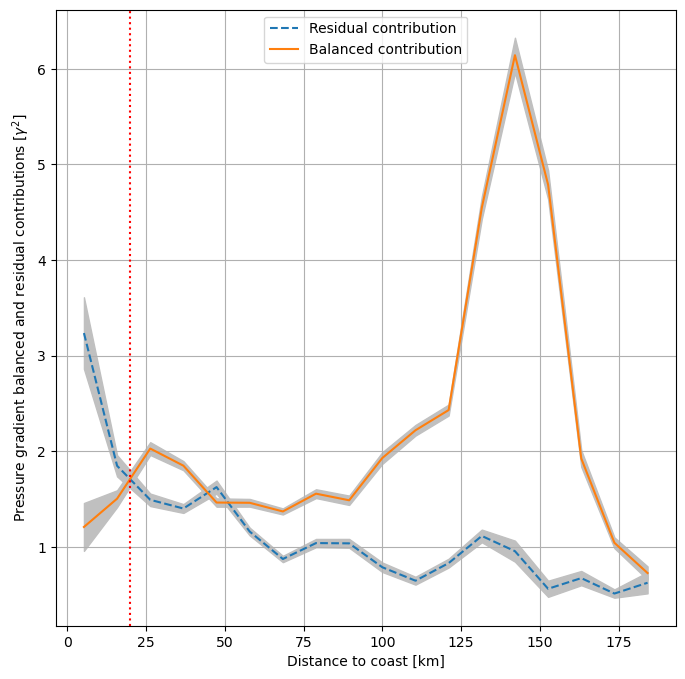

In [6]:
plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(1, 1, figsize=(8,8), frameon=False)
#dsdtc.Ex_ggd.plot(ax=ax, label='x')
#dsdtc.Ey_ggd.plot(ax=ax, label='y')
dsdtc.E_ggd.plot(ax=ax, ls='--', label = 'Residual contribution')
dsdtc['ser__E_ggd'] = dsdtc.ser__Ee_ggd + dsdtc.ser__En_ggd
plot_error(dsdtc, 'dtc_cut', 'E_ggd', ax=ax, suf='ser__')
#c = dsdtc.dtc_cut
#coef = np.polyfit(c, dsdtc.E_ggd, 1, w =dsdtc.nb_coloc)
#ax.plot(c, coef[0]*c  +coef[1])


dsdtc.B_ggd.plot(ax=ax, label = 'Balanced contribution')
dsdtc['ser__B_ggd'] = dsdtc.ser__Be_ggd + dsdtc.ser__Bn_ggd
plot_error(dsdtc, 'dtc_cut', 'B_ggd', ax=ax, suf='ser__')
#c = dsdtc.dtc_cut
#coef = np.polyfit(c, dsdtc.B_ggd, 1, w =dsdtc.nb_coloc)
#ax.plot(c, coef[0]*c  +coef[1])
ax.axvline(20, ls=':',c='r' )
ax.grid()
ax.set_ylabel(r'Pressure gradient balanced and residual contributions [$\gamma^2$]')
ax.set_xlabel(r'Distance to coast [km]')
ax.legend()

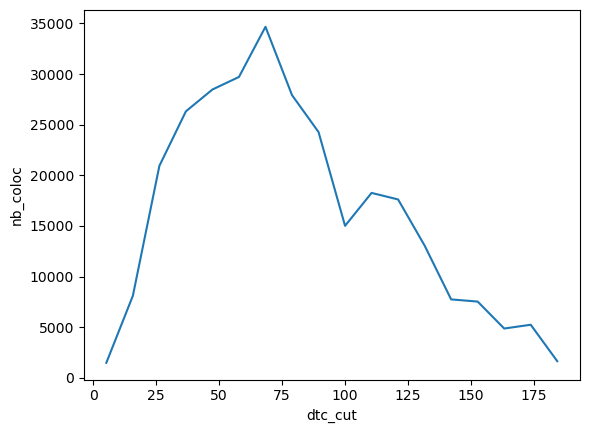

In [11]:
dsdtc.nb_coloc.plot()

In [21]:
df.distance_to_coast

row_number
144       86061.107134
145       86061.511544
146       86061.338059
147       85902.733965
148       85912.691098
              ...     
376574    24052.457241
376575    24252.587945
376576    24270.673703
376577    24286.224917
376578    24297.201671
Name: distance_to_coast, Length: 292884, dtype: float64

In [34]:
dfr_ = df[(df.distance_to_coast>125e3) & (df.distance_to_coast<175e3)]
dfr_ = dfr_[((dfr_.ggde**2+dfr_.ggdn**2)/U2)>5]

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '


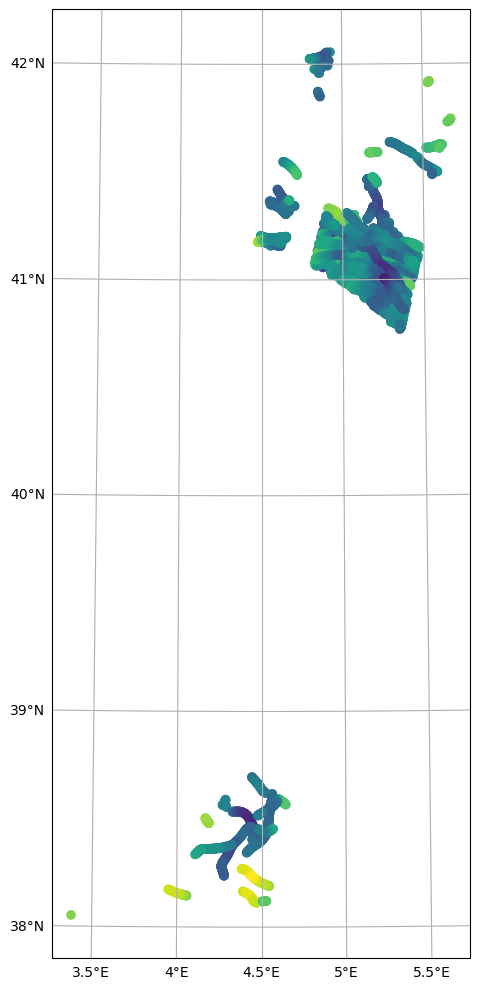

In [35]:
fig = plt.figure(figsize=(10,10))
fig.patch.set_facecolor('white')#no transparancy in png
ax = fig.add_subplot(111, projection=ccrs.Orthographic(4.5, 40))
ax.scatter(dfr_.longitude, dfr_.latitude, c = dfr_.ggde.values,  transform=crs)
#ax.add_feature(cfeature.LAND,)
gl = ax.gridlines(draw_labels=True,)
gl.xlabels_top = False
gl.ylabels_right = False

#ax.set_title(f'SWOT-2km {pd.to_datetime(dss3.time.mean().values).strftime("%m-%d-%Y")}\n Drifters from {dtmin} to {dtmax}')
fig.tight_layout()